# Setup

In [30]:
!pip install numpy

### Kaggle configuration

In [27]:
import sys
import os
import shutil

sys.path.append("/kaggle/input/datasets/esraahassan0/preprocess")
sys.path.append("/kaggle/input/datasets/esraahassan0/model-v0")
sys.path.append("/kaggle/input/datasets/esraahassan0/dataloader")
sys.path.append("/kaggle/input/datasets/esraahassan0/feature-extraction-v0")
# shutil.copytree(
#     "/kaggle/input/datasets/esraahassan0/model-v0",
#     "/kaggle/working/model_v0"
# )
# shutil.copytree(
#     "/kaggle/input/datasets/esraahassan0/train-v0",
#     "/kaggle/working/train_v0"
# )
# shutil.copytree(
#     "/kaggle/input/datasets/esraahassan0/dataloader",
#     "/kaggle/working/dataloader"
# )

'/kaggle/working/train_v0'

## Dataloading and features extraction

In [4]:
# Import required modules
import os
import numpy as np
import shutil
from sklearn.model_selection import train_test_split

# Import from local modules
from preprocess import preprocess_single_audio, get_audio_files
import feature_extraction
from feature_extraction.MFCC import MfccExtractor

In [5]:
# Configuration
INPUT_DATASET_PATH = "/kaggle/input/datasets/alieldinalaa/nn-cmp27-dataset"  # Path to original dataset
OUTPUT_BASE_PATH = '/kaggle/working/processed_data'

TRAIN_PATH = os.path.join(OUTPUT_BASE_PATH, 'train')
TEST_PATH = os.path.join(OUTPUT_BASE_PATH, 'test')
VAL_PATH = os.path.join(OUTPUT_BASE_PATH, 'validation')

TEST_SIZE = 0.15  # 15% for test
VAL_SIZE = 0.15  # 15% of train for validation

# Create output directories
os.makedirs(TRAIN_PATH, exist_ok=True)
os.makedirs(TEST_PATH, exist_ok=True)
os.makedirs(VAL_PATH, exist_ok=True)

print(f"Output base: {OUTPUT_BASE_PATH}")
print(f"Train: {TRAIN_PATH}")
print(f"Test: {TEST_PATH}")
print(f"Validation: {VAL_PATH}")

Output base: /kaggle/working/processed_data
Train: /kaggle/working/processed_data/train
Test: /kaggle/working/processed_data/test
Validation: /kaggle/working/processed_data/validation


In [6]:
# Get all audio files and their class labels
def get_all_audio_files_with_labels(base_path):
    """
    Scans the dataset directory and returns a list of (file_path, class_label) tuples.
    Expected structure: base_path/Machine X/machine_data/Normal or Abnormal
    """
    audio_files = []
    
    if os.path.isdir(base_path):
        for machine_name in sorted(os.listdir(base_path)):
            machine_path = os.path.join(base_path, machine_name)
            if os.path.isdir(machine_path):
                for subfolder in sorted(os.listdir(machine_path)):
                    subfolder_path = os.path.join(machine_path, subfolder)
                    if os.path.isdir(subfolder_path):
                        for state_name in sorted(os.listdir(subfolder_path)):
                            state_path = os.path.join(subfolder_path, state_name)
                            if os.path.isdir(state_path):
                                label = f"{machine_name}_{state_name}"
                                for root, dirs, files in os.walk(state_path):
                                    for file in sorted(files):
                                        if file.lower().endswith(('.wav', '.mp3', '.flac', '.ogg')):
                                            audio_files.append((os.path.join(root, file), label))
    
    return audio_files

# Get all files
all_files = get_all_audio_files_with_labels(INPUT_DATASET_PATH)
print(f"Total audio files found: {len(all_files)}")

# Show class distribution
from collections import Counter
class_counts = Counter([label for _, label in all_files])
print("\nClass distribution:")
for cls, count in sorted(class_counts.items()):
    print(f"  {cls}: {count}")

Total audio files found: 56236

Class distribution:
  Machine 1_Abnormal: 3176
  Machine 1_Normal: 16200
  Machine 2_Abnormal: 3240
  Machine 2_Normal: 16200
  Machine 3_Abnormal: 3020
  Machine 3_Normal: 14400


In [7]:
# Split into train, test, validation
# First split: train vs test
train_files, test_files = train_test_split(
    all_files, 
    test_size=TEST_SIZE, 
    random_state=42,
    stratify=[label for _, label in all_files]
)

# Second split: train vs validation
train_files, val_files = train_test_split(
    train_files, 
    test_size=VAL_SIZE, 
    random_state=42,
    stratify=[label for _, label in train_files]
)

print(f"Train files: {len(train_files)}")
print(f"Test files: {len(test_files)}")
print(f"Validation files: {len(val_files)}")

Train files: 40630
Test files: 8436
Validation files: 7170


In [8]:
# Process audio files with preprocessing and MFCC extraction
def process_and_save_files(file_list, output_base_path, mfcc_extractor):
    """
    Process audio files: preprocess + MFCC extraction and save features.
    """
    features_list = []
    labels_list = []
    
    for file_path, class_label in file_list:
        try:
            # Preprocess audio
            y_clean, sr = preprocess_single_audio(file_path)
            
            # Extract MFCC features
            mfcc_features = mfcc_extractor.process(y_clean)
            
            features_list.append(mfcc_features)
            labels_list.append(class_label)
            
        except Exception as e:
            print(f"Error processing {file_path}: {e}")
    
    return features_list, labels_list

# Initialize MFCC extractor
mfcc_extractor = MfccExtractor(
    sample_rate=16000,
    n_fft=2048,
    n_mels=40,
    hop_length=2048,
    n_mfcc=40
)

In [9]:
import pickle

def load_features_and_labels(pkl_file_path):
    """Loads features and labels from a pickle file."""
    with open(pkl_file_path, 'rb') as f:
        data = pickle.load(f)
        
    if isinstance(data, dict):
        features_list = data['features']
        raw_labels_list = data['labels']
    elif isinstance(data, (tuple, list)) and len(data) == 2:
        features_list, raw_labels_list = data
    else:
        raise ValueError("Unrecognized data structure in the pickle file.")
        
    return features_list, raw_labels_list

### Generate features files (for the first time)

In [ ]:
# # Process training data
# print("Processing training data...")
# train_features, train_labels = process_and_save_files(train_files, TRAIN_PATH, mfcc_extractor)
# print(f"Processed {len(train_features)} training samples")

In [ ]:
# # Process test data
# print("Processing test data...")
# test_features, test_labels = process_and_save_files(test_files, TEST_PATH, mfcc_extractor)
# print(f"Processed {len(test_features)} test samples")

In [ ]:
# # Process validation data
# print("Processing validation data...")
# val_features, val_labels = process_and_save_files(val_files, VAL_PATH, mfcc_extractor)
# print(f"Processed {len(val_features)} validation samples")

In [ ]:
# Save processed data
import pickle

# # Save training data
# with open(os.path.join(OUTPUT_BASE_PATH, 'train/train_data.pkl'), 'wb') as f:
#     pickle.dump({'features': train_features, 'labels': train_labels}, f)

# # Save test data
# with open(os.path.join(OUTPUT_BASE_PATH, 'test/test_data.pkl'), 'wb') as f:
#     pickle.dump({'features': test_features, 'labels': test_labels}, f)

# Save validation data
# with open(os.path.join(OUTPUT_BASE_PATH, 'validation/val_data.pkl'), 'wb') as f:
#     pickle.dump({'features': val_features, 'labels': val_labels}, f)

# print(f"\nData saved to {OUTPUT_BASE_PATH}")

In [11]:
# # Verify data shapes
# print("Data Summary:")
# print(f"Train: {len(train_features)} samples")
# if train_features:
#     print(f"  Feature shape: {train_features[0].shape if hasattr(train_features[0], 'shape') else 'N/A'}")

# print(f"Test: {len(test_features)} samples")
# if test_features:
#     print(f"  Feature shape: {test_features[0].shape if hasattr(test_features[0], 'shape') else 'N/A'}")

# print(f"Validation: {len(val_features)} samples")
# if val_features:
#     for i in range(1,2):
#         print(f"  Feature shape: {val_features[i].shape if hasattr(val_features[i], 'shape') else 'N/A'}")

### Load features files from kaggle working dir

In [12]:
train_features, train_labels= load_features_and_labels("/kaggle/working/processed_data/train/train_data.pkl")
test_features, test_labels= load_features_and_labels("/kaggle/working/processed_data/test/test_data.pkl")
val_features, val_labels= load_features_and_labels("/kaggle/working/processed_data/validation/val_data.pkl")


In [13]:
import pickle
def inspect_pkl(file_path):
    with open(file_path, 'rb') as f:
        data = pickle.load(f)
    
    if isinstance(data, dict):
        print(f"Keys: {data.keys()}")
        print(f"Number of features: {len(data.get('features', []))}")
        labels = data.get('labels', [])
        print(f"Number of labels: {len(labels)}")
        print(f"Unique labels: {set(labels)}")
    else:
        print(f"Data type: {type(data)}")
        print(f"Length: {len(data)}")
inspect_pkl('/kaggle/working/processed_data/train/train_data.pkl')

Keys: dict_keys(['features', 'labels'])
Number of features: 40630
Number of labels: 40630
Unique labels: {'Machine 3_Normal', 'Machine 1_Abnormal', 'Machine 2_Abnormal', 'Machine 3_Abnormal', 'Machine 1_Normal', 'Machine 2_Normal'}


# Model Training, Testing, and Validation

### Training

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.preprocessing import LabelEncoder

In [15]:
# Create label encoder
label_encoder = LabelEncoder()
all_labels = val_labels+test_labels+train_labels
label_encoder.fit(all_labels)

num_classes = len(label_encoder.classes_)
print(f"Number of classes: {num_classes}")
print(f"Classes: {label_encoder.classes_}")

Number of classes: 6
Classes: ['Machine 1_Abnormal' 'Machine 1_Normal' 'Machine 2_Abnormal'
 'Machine 2_Normal' 'Machine 3_Abnormal' 'Machine 3_Normal']


In [16]:
# Convert labels to numeric
train_labels_enc = label_encoder.transform(train_labels)
test_labels_enc = label_encoder.transform(test_labels)
val_labels_enc = label_encoder.transform(val_labels)
from dataset import AudioDataset

In [17]:
# Create datasets and dataloaders
train_dataset = AudioDataset(train_features, train_labels_enc)
test_dataset = AudioDataset(test_features, test_labels_enc)
val_dataset = AudioDataset(val_features, val_labels_enc)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")
print(f"Validation batches: {len(val_loader)}")

Train batches: 1270
Test batches: 264
Validation batches: 225


In [18]:
import importlib
import model_v0, train_v0.train
from model import AudioClassifier
# Force reload the module from disk
importlib.reload(train_v0.train)

from train_v0.train import Trainer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = AudioClassifier(num_classes=num_classes)

print(f"Device: {device}")

Device: cuda


In [19]:
trainer = Trainer(model, train_loader, val_loader, device=device)

In [20]:
history = trainer.fit(num_epochs=75)
best_val_acc = trainer.best_val_acc

print(f"Best Validation Accuracy: {best_val_acc:.2f}%")

Epoch   1 | Train Loss: 0.3289 | Train Acc: 88.57% | Val Loss: 0.1580 | Val Acc: 94.91%
--> Saved checkpoint: /kaggle/working/checkpoints/model_epoch_5.pth
--> Saved checkpoint: /kaggle/working/checkpoints/model_epoch_10.pth
Epoch  10 | Train Loss: 0.0144 | Train Acc: 99.47% | Val Loss: 0.0405 | Val Acc: 98.72%
--> Saved checkpoint: /kaggle/working/checkpoints/model_epoch_15.pth
--> Saved checkpoint: /kaggle/working/checkpoints/model_epoch_20.pth
Epoch  20 | Train Loss: 0.0070 | Train Acc: 99.72% | Val Loss: 0.0189 | Val Acc: 99.43%
--> Saved checkpoint: /kaggle/working/checkpoints/model_epoch_25.pth
--> Saved checkpoint: /kaggle/working/checkpoints/model_epoch_30.pth
Epoch  30 | Train Loss: 0.0048 | Train Acc: 99.84% | Val Loss: 0.0188 | Val Acc: 99.57%
--> Saved checkpoint: /kaggle/working/checkpoints/model_epoch_35.pth
--> Saved checkpoint: /kaggle/working/checkpoints/model_epoch_40.pth
Epoch  40 | Train Loss: 0.0069 | Train Acc: 99.80% | Val Loss: 0.0295 | Val Acc: 99.30%
--> Saved

### Uncomment to resume training

In [ ]:
# # 2. Load the latest weights into the model
# # It will return 0 if no checkpoints exist, or the epoch number if it found one
# last_epoch = trainer.load_latest_checkpoint()

# # 3. Initialize the Trainer with the newly loaded model
# trainer = Trainer(
#     model=model, 
#     train_loader=train_loader, 
#     val_loader=val_loader, 
#     device=device,
#     lr=0.001
# )

# # 4. Calculate remaining epochs
# target_total_epochs = 75
# remaining_epochs = target_total_epochs - last_epoch

# if remaining_epochs > 0:
#     print(f"Starting/Resuming training for {remaining_epochs} epochs...")
#     # Run the fit method for just the remaining amount
#     history = trainer.fit(num_epochs=remaining_epochs)
# else:
#     print("Model has already completed the target number of epochs!")

# Inference

In [28]:
import train_v0.test
from train_v0.test import ModelEvaluator

Final Test Loss: 0.0160
Final Test Accuracy: 99.68%

Inference Timing Analysis
Total Inference Time:  0.6516 sec
Average Time/Sample:   0.08 ms
Worst Batch Time:      4.60 ms
Worst Time/Sample:     0.23 ms

Classification Report
                    precision    recall  f1-score   support

Machine 1_Abnormal       1.00      0.98      0.99       477
  Machine 1_Normal       1.00      1.00      1.00      2430
Machine 2_Abnormal       0.99      0.99      0.99       486
  Machine 2_Normal       1.00      1.00      1.00      2430
Machine 3_Abnormal       1.00      0.99      0.99       453
  Machine 3_Normal       1.00      1.00      1.00      2160

          accuracy                           1.00      8436
         macro avg       1.00      0.99      0.99      8436
      weighted avg       1.00      1.00      1.00      8436



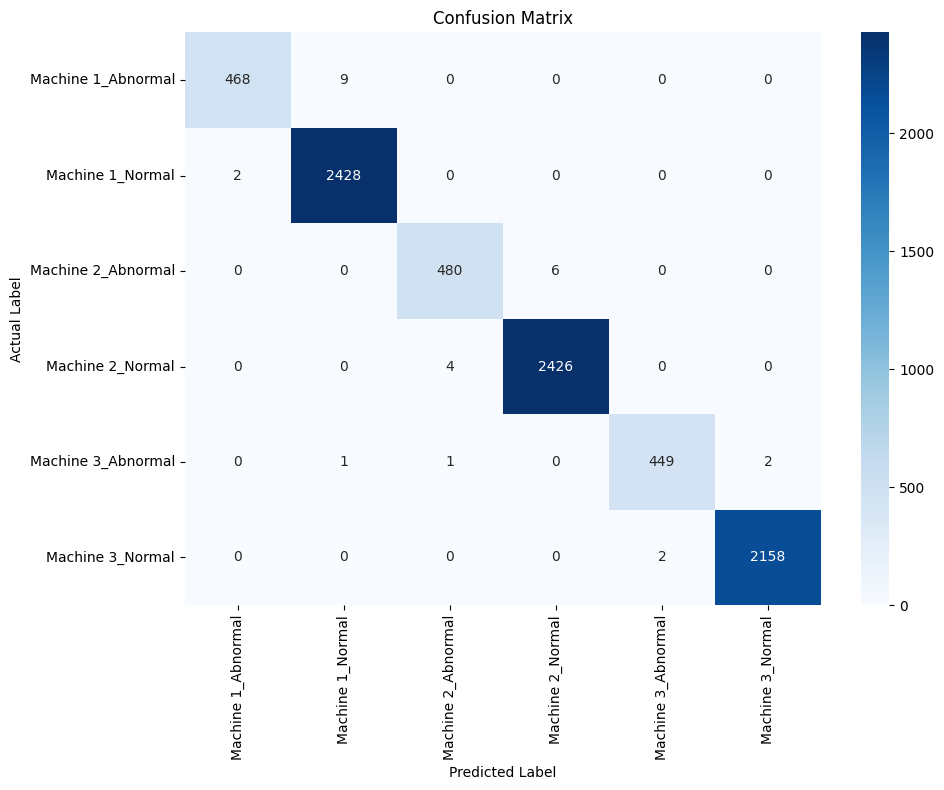

In [29]:
# 1. Initialize the updated evaluator
evaluator = ModelEvaluator(
    model=model, 
    test_loader=test_loader, 
    device=device, 
    class_names=label_encoder.classes_
)

# 2. Extract metrics, including the new timing_stats dictionary
test_loss, test_accuracy, actual_labels, predicted_labels, timing_stats = evaluator.evaluate()

print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_accuracy:.2f}%\n")

# 3. Print the text report with worst-case timing bounds
evaluator.print_report(actual_labels, predicted_labels, timing_stats)

# 4. Show the confusion matrix
evaluator.plot_confusion_matrix(actual_labels, predicted_labels)